In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#### What is NYC 311?
```
NYC 311 is New York City’s official non‑emergency service system where residents report issues such as noise complaints, heat/hot water problems, illegal parking, sanitation issues, and more. These reports flow into a public dataset containing millions of records used by city agencies to monitor service quality and allocate resources.
```

#### Problem Statement (NYC 311 ETL Project)
```
1. NYC agencies need a reliable, analytics‑ready dataset of 311 service requests to understand community issues, track operational performance, and identify patterns such as high‑volume complaint types or slow response times.

2. The raw 311 API data is messy, inconsistent, and not directly usable for analysis—timestamps vary, fields are missing, complaint types are unstandardized, and records must be filtered and transformed—requiring an ETL pipeline that cleans, structures, and enriches the data for reporting and decision‑making.
```

# NYC 311 API + ETL Example
This notebook demonstrates a realistic data engineering workflow:
- Calling a public REST API (NYC Open Data)
- Inspecting JSON
- Converting to pandas DataFrame
- Cleaning timestamps
- Selecting relevant fields
- Filtering records
- Adding derived columns
- Exporting ETL output
- Visualizing service request trends

In [7]:
# Step 1: Call NYC 311 Service Requests API
# We fetch the latest 50 service requests.
import requests

url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=500"
response = requests.get(url)
data = response.json()

data[:3]  # show first 3 records

[{'unique_key': '69639237',
  'created_date': '2026-07-08T02:11:18.000',
  'agency': 'DOT',
  'agency_name': 'Department of Transportation',
  'complaint_type': 'Street Condition',
  'descriptor': 'Pothole',
  'incident_zip': '11378',
  'incident_address': '63 STREET',
  'street_name': '63 STREET',
  'cross_street_1': '54 AVENUE',
  'cross_street_2': 'LIE WESTBOUND EXIT   18',
  'address_type': 'BLOCKFACE',
  'city': 'QUEENS',
  'facility_type': 'N/A',
  'status': 'Open',
  'resolution_description': 'The Department of Transportation referred this complaint to the appropriate Maintenance Unit for repair.',
  'resolution_action_updated_date': '2026-07-08T02:11:18.000',
  'community_board': '05 QUEENS',
  'police_precinct': 'Precinct 104',
  'borough': 'QUEENS',
  'open_data_channel_type': 'UNKNOWN',
  'park_facility_name': 'Unspecified',
  'park_borough': 'QUEENS'},
 {'unique_key': '69639521',
  'created_date': '2026-07-08T01:51:01.000',
  'agency': 'NYPD',
  'agency_name': 'New York Cit

### API JSON Structure
Important fields:
- `created_date`: when the complaint was logged
- `closed_date`: when it was resolved
- `complaint_type`: category of issue
- `descriptor`: detailed description
- `borough`: NYC borough
- `latitude`, `longitude`: location

In [8]:
# Step 2: Convert JSON to pandas DataFrame
import pandas as pd

df = pd.DataFrame(data)
df.head()

,unique_key,created_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,cross_street_1,...,location,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_sbqj_enih,:@computed_region_92fq_4b7q,descriptor_2,vehicle_type,closed_date,taxi_pick_up_location,taxi_company_borough
0,69639237,2026-07-08T02:11:18.000,DOT,Department of Transportation,Street Condition,Pothole,11378,63 STREET,63 STREET,54 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,69639521,2026-07-08T01:51:01.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,11421,76-24 85 ROAD,85 ROAD,76 STREET,...,"{'type': 'Point', 'coordinates': [-73.86585096...",46,3,60,34,NaN,NaN,NaN,NaN,NaN
2,69634788,2026-07-08T01:50:16.000,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,11208,250 BERRIMAN STREET,BERRIMAN STREET,BELMONT AVENUE,...,"{'type': 'Point', 'coordinates': [-73.87944641...",45,2,47,25,NaN,NaN,NaN,NaN,NaN
3,69642732,2026-07-08T01:50:02.000,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,11420,116-22 126 STREET,126 STREET,116 AVENUE,...,"{'type': 'Point', 'coordinates': [-73.81230723...",62,3,64,46,NaN,NaN,NaN,NaN,NaN
4,69641154,2026-07-08T01:49:41.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,10002,244 EAST HOUSTON STREET,EAST HOUSTON STREET,AVENUE A,...,"{'type': 'Point', 'coordinates': [-73.98580390...",70,4,5,50,NaN,NaN,NaN,NaN,NaN


### ETL Steps
We will:
1. Convert timestamps
2. Select relevant columns
3. Filter only 'Noise' complaints
4. Add a derived column: time to resolve (in hours)
5. Clean column names

In [9]:
# Step 3: ETL Transformations

# Convert timestamps
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

# Select relevant columns
cols = ['created_date', 'closed_date', 'complaint_type', 'descriptor', 'borough', 'latitude', 'longitude']
df2 = df[cols].copy()

# Filter only Noise complaints
df_noise = df2[df2['complaint_type'] == 'Noise'].copy()

# Add derived column: time to resolve
df_noise['hours_to_resolve'] = (df_noise['closed_date'] - df_noise['created_date']).dt.total_seconds() / 3600

df_noise.head()

,created_date,closed_date,complaint_type,descriptor,borough,latitude,longitude,hours_to_resolve
408,2026-07-07 23:57:00,NaT,Noise,Noise: Alarms (NR3),QUEENS,40.76212182334035,-73.8651516715465,NaN
419,2026-07-07 23:54:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),MANHATTAN,40.75853639347696,-73.99480214519946,NaN
462,2026-07-07 23:47:00,NaT,Noise,Noise: Alarms (NR3),BROOKLYN,40.66754457783722,-73.99104593223109,NaN
478,2026-07-07 23:46:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),QUEENS,40.75017073760437,-73.91317422887185,NaN
490,2026-07-07 23:44:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),MANHATTAN,40.75778441171407,-73.9970004384904,NaN


In [10]:
# Step 4: Export ETL output
df_noise.to_csv("nyc_311_noise_etl.csv", index=False)
df_noise.head()

,created_date,closed_date,complaint_type,descriptor,borough,latitude,longitude,hours_to_resolve
408,2026-07-07 23:57:00,NaT,Noise,Noise: Alarms (NR3),QUEENS,40.76212182334035,-73.8651516715465,NaN
419,2026-07-07 23:54:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),MANHATTAN,40.75853639347696,-73.99480214519946,NaN
462,2026-07-07 23:47:00,NaT,Noise,Noise: Alarms (NR3),BROOKLYN,40.66754457783722,-73.99104593223109,NaN
478,2026-07-07 23:46:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),QUEENS,40.75017073760437,-73.91317422887185,NaN
490,2026-07-07 23:44:00,NaT,Noise,Noise: Construction Before/After Hours (NM1),MANHATTAN,40.75778441171407,-73.9970004384904,NaN


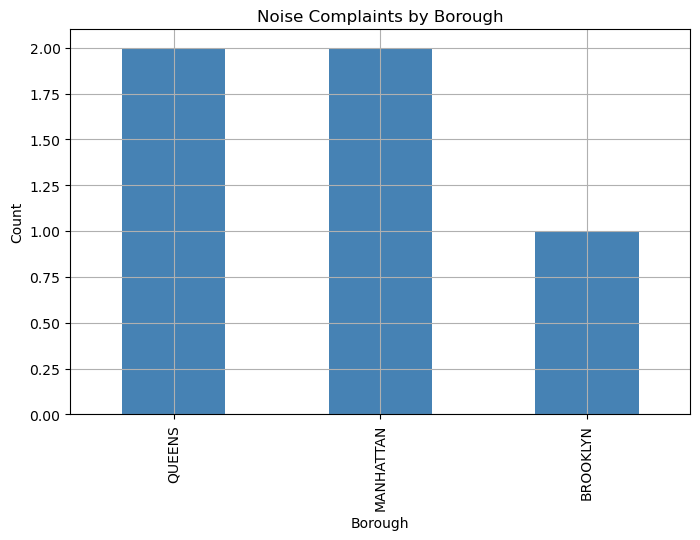

In [11]:
# Step 5: Visualization — Noise complaints by borough
import matplotlib.pyplot as plt

counts = df_noise['borough'].value_counts()

if counts.empty:
    print("No Noise complaints found in this API batch. Try increasing the limit or using a different complaint type.")
else:
    plt.figure(figsize=(8,5))
    counts.plot(kind='bar', color='steelblue')
    plt.title('Noise Complaints by Borough')
    plt.xlabel('Borough')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()
